# Factory-to-Customer Shipping Route Efficiency Analysis
### Nassau Candy Distributor

**Objective:** identify which factory → customer routes are efficient or inefficient, where geographic
bottlenecks are, how ship modes compare, and what Nassau Candy can change to ship faster and cheaper.

**Notebook outline**
1. Setup & data loading
2. Data quality audit (including the lead-time date-shift finding)
3. KPI overview
4. Ship-mode performance
5. Delay trend over time
6. Route efficiency leaderboard
7. Geographic bottlenecks (state level, with confidence intervals)
8. Does distance drive lead time? (statistical tests)
9. Factory network & sourcing scenarios
10. Conclusions & recommendations

> All cleaning logic lives in `src/data_prep.py` and all KPI logic in `src/metrics.py`, so the notebook,
> the report and the Streamlit app share one definition of every number.

## 1. Setup & data loading

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

from src import config, data_prep, metrics as m

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

FIG = config.FIGURES_DIR; FIG.mkdir(parents=True, exist_ok=True)
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
})
def save(fig, name):
    fig.savefig(FIG / f"{name}.png", facecolor="white"); plt.show()

In [2]:
raw = data_prep.load_raw()
print(raw.shape)
raw.head()

(10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
# Run the full cleaning pipeline (same code as `python -m src.data_prep`)
df, dq = data_prep.clean(data_prep.load_raw())
data_prep.save(df)
df = m.add_excess_days(df)
pd.Series(dq, name="value").to_frame()

,value
rows_raw,10194
missing_values,0
duplicate_rows,0
max_profit_identity_error,0.00
ship_before_order,0
zip_codes_padded,449
unmapped_products,0
ungeocoded_rows,0
raw_lead_time_range,"(904, 1642)"
adjusted_lead_time_range,"(0, 11)"


## 2. Data quality audit

| Check | Result |
|---|---|
| Missing values / duplicate rows | none |
| `Sales − Cost = Gross Profit` | holds for every row (max error ≈ 1e-14) |
| US ZIP codes that lost a leading zero (New England, NJ) | 449 rows padded back to 5 digits |
| Products without a factory | 0 – all 15 products map to one of 5 factories |
| Customers that could not be geocoded | 0 (US: ZIP centroid, Canada: city centroid) |

### Key finding: the raw Ship Date − Order Date gap is not a real lead time
The brief defines **Shipping Lead Time = Ship Date − Order Date**. Computed literally it ranges from
**904 to 1,642 days (2.5–4.5 years)** – impossible for confectionery with a shelf life of months.
The plots below show why we treat it as a systematic date-shift in the source system:

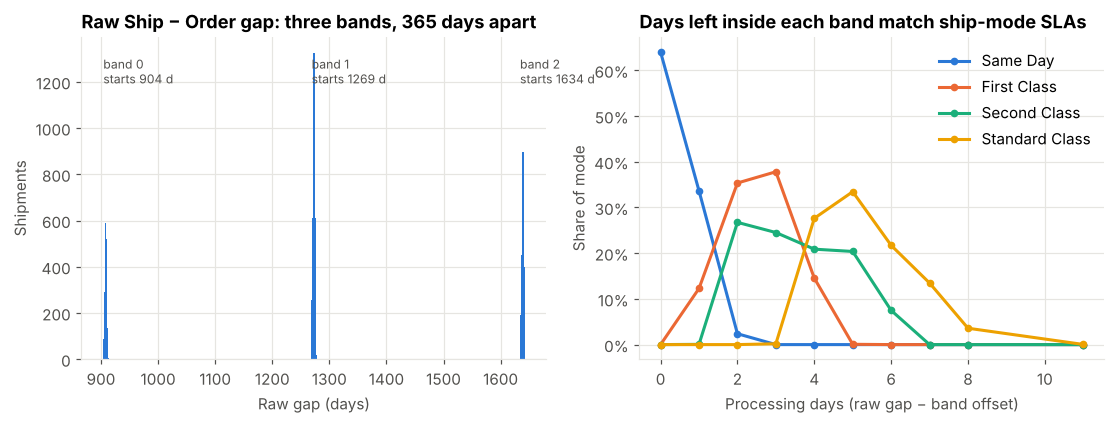

lead_time_days,0,1,2,3,4,5,6,7,8,11
Ship Mode,,,,,,,,,,
Same Day,350,184,13,0,0,0,0,0,0,0
First Class,0,190,547,585,225,1,0,0,0,0
Second Class,0,1,529,485,413,403,148,0,0,0
Standard Class,0,0,0,11,1690,2046,1328,824,219,2


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
vc = df["raw_lead_time_days"].value_counts().sort_index()
ax[0].bar(vc.index, vc.values, width=2.5, color="#2a78d6")
ax[0].set_title("Raw Ship − Order gap: three bands, 365 days apart")
ax[0].set_xlabel("Raw gap (days)"); ax[0].set_ylabel("Shipments")
for b, x in zip(range(3), [904, 1269, 1634]):
    ax[0].annotate(f"band {b}\nstarts {x} d", (x, vc.max()*0.9), color=MUTED, fontsize=8)

ct = pd.crosstab(df["Ship Mode"], df["lead_time_days"]).reindex(config.SHIP_MODE_ORDER)
for mode in config.SHIP_MODE_ORDER:
    ax[1].plot(ct.columns, ct.loc[mode] / ct.loc[mode].sum(), marker="o", ms=4, lw=2,
               color=m.SHIP_MODE_COLORS[mode], label=mode)
ax[1].set_title("Days left inside each band match ship-mode SLAs")
ax[1].set_xlabel("Processing days (raw gap − band offset)"); ax[1].set_ylabel("Share of mode")
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax[1].legend(frameon=False)
save(fig, "fig01_lead_time_decomposition")

pd.crosstab(df["Ship Mode"], df["lead_time_days"]).reindex(config.SHIP_MODE_ORDER)

**Interpretation.** Every raw gap equals `904 + 365·k + d`, where *k* ∈ {0, 1, 2} is a whole-year band
and *d* is 0–8 days. Within any band, *d* follows the ship-mode hierarchy exactly
(Same Day 0–2 → First 1–4 → Second 2–6 → Standard 3–8). That pattern could not survive if the
whole gap were noise, so *d* is the true **order-processing lead time** and the band offset is a
year-level date-shift introduced when the data was prepared.

**Decision:** all KPIs use `lead_time_days = (raw gap − 904) mod 365`. The raw gap is kept in the dataset
(`raw_lead_time_days`) and can be toggled on in the dashboard for transparency.

**Delay definition:** a shipment is *delayed* if its processing time exceeds the SLA for its ship mode
(Same Day ≤ 1 d, First ≤ 3 d, Second ≤ 5 d, Standard ≤ 6 d – roughly each mode's 75th percentile).
The dashboard also lets the user replace this with one global threshold.

## 3. KPI overview

In [5]:
k = m.headline_kpis(df)
pd.Series({
    "Shipments (order lines)": f"{k['shipments']:,}",
    "Unique orders": f"{k['orders']:,}",
    "Factory→state routes": k["routes"],
    "Average lead time": f"{k['avg_lead_time']:.2f} days",
    "Delay frequency (SLA breach)": f"{k['delay_rate']:.1%}",
    "Average route distance": f"{k['avg_distance']:,.0f} mi",
    "Sales": f"${k['sales']:,.0f}",
    "Gross profit": f"${k['gross_profit']:,.0f}",
}, name="value").to_frame()

,value
Shipments (order lines),"10,194"
Unique orders,"8,549"
Factory→state routes,196
Average lead time,4.29 days
Delay frequency (SLA breach),14.0%
Average route distance,"1,248 mi"
Sales,"$141,784"
Gross profit,"$93,443"


In [6]:
fac = df.groupby("Factory").agg(Shipments=("Sales", "size"), Sales=("Sales", "sum"),
                                Avg_mi=("distance_miles", "mean"), Avg_lead=("lead_time_days", "mean"),
                                Delay=("is_delayed", "mean"))
fac["Share"] = fac["Shipments"] / fac["Shipments"].sum()
fac.sort_values("Shipments", ascending=False)

,Shipments,Sales,Avg_mi,Avg_lead,Delay,Share
Factory,,,,,,
Lot's O' Nuts,5692,"76,340.15","1,332.54",4.26,0.14,0.56
Wicked Choccy's,4152,"55,352.75","1,157.98",4.35,0.15,0.41
Secret Factory,217,"8,587.50",892.73,4.09,0.13,0.02
The Other Factory,100,"1,282.25","1,021.54",3.98,0.13,0.01
Sugar Shack,33,220.98,"1,116.33",4.67,0.12,0.00


## 4. Ship-mode performance

,Shipments,Share,Avg Lead Time (d),Median Lead Time (d),SLA (d),Delay Rate,Avg Distance (mi),Gross Margin %
Ship Mode,,,,,,,,
Same Day,547,0.05,0.38,0.00,1,0.02,"1,236.52",66.08
First Class,1548,0.15,2.55,3.00,3,0.15,"1,253.23",65.72
Second Class,1979,0.19,3.57,3.00,5,0.07,"1,250.74",65.71
Standard Class,6120,0.60,5.32,5.00,6,0.17,"1,247.36",66.00


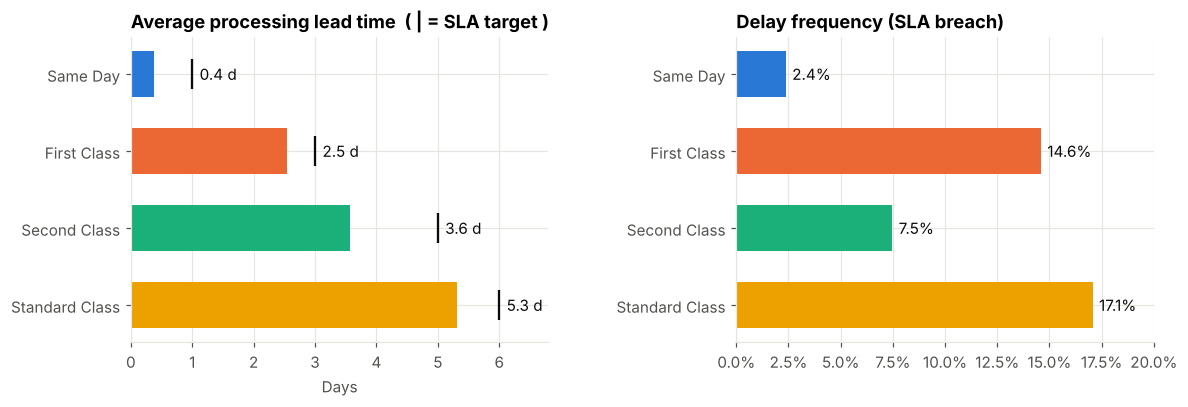

In [7]:
sm = m.ship_mode_summary(df); display(sm)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"wspace": 0.45})
cols = [m.SHIP_MODE_COLORS[x] for x in sm.index]
ax[0].barh(sm.index, sm["Avg Lead Time (d)"], color=cols, height=0.6)
ax[0].scatter(sm["SLA (d)"], sm.index, marker="|", s=400, color=INK, zorder=3, label="SLA target")
ax[0].invert_yaxis(); ax[0].set_title("Average processing lead time  ( | = SLA target )"); ax[0].set_xlabel("Days")
ax[0].set_xlim(0, 6.8)
for i, (v, t) in enumerate(zip(sm["Avg Lead Time (d)"], sm["SLA (d)"])):
    ax[0].text(max(v, t) + .12, i, f"{v:.1f} d", va="center", color=INK)
ax[1].barh(sm.index, sm["Delay Rate"], color=cols, height=0.6); ax[1].invert_yaxis(); ax[1].set_xlim(0, 0.2)
ax[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax[1].set_title("Delay frequency (SLA breach)")
for i, v in enumerate(sm["Delay Rate"]): ax[1].text(v + .003, i, f"{v:.1%}", va="center", color=INK)
save(fig, "fig02_ship_mode_performance")

**Findings.** Ship mode is the dominant driver of lead time: Same Day ships in 0.4 days on average,
Standard Class in 5.3. Standard Class carries **60% of all volume** and has the highest SLA breach rate
(≈17%), followed by First Class (≈15%) – First Class customers pay for speed but miss their 3-day target
roughly one time in seven. Gross margin is flat (~66%) across modes because the dataset does not record
freight cost, so faster modes look "free" here; real freight cost should be added before re-pricing modes.

## 5. Delay trend over time

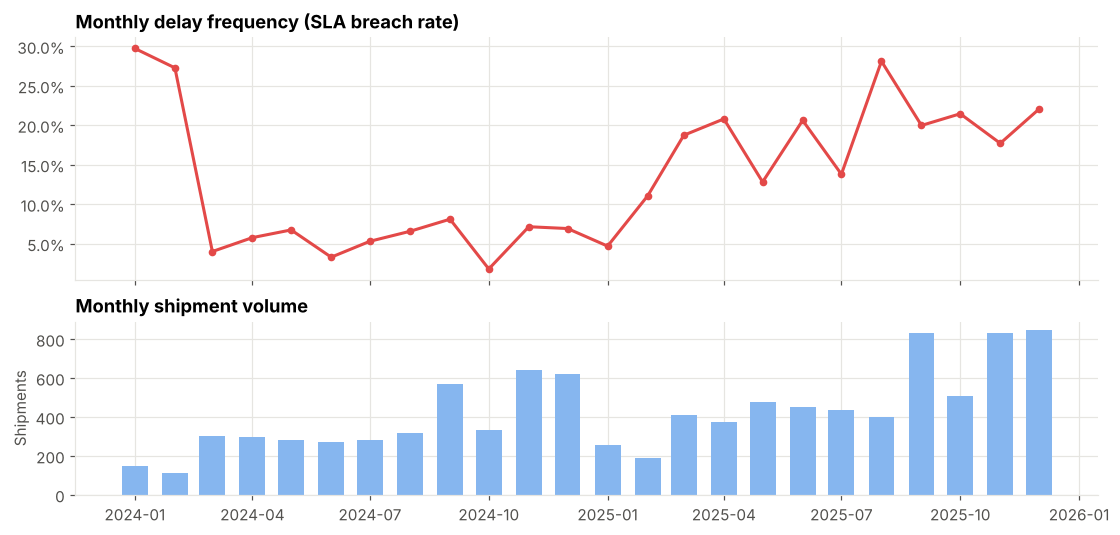

Half,2024-H1,2024-H2,2025-H1,2025-H2
Ship Mode,,,,
Same Day,0.0%,0.0%,4.3%,3.5%
First Class,5.4%,0.0%,19.0%,24.4%
Second Class,2.6%,0.0%,8.9%,13.8%
Standard Class,12.5%,10.6%,18.3%,23.0%


In [8]:
mon = df.groupby("Order Month").agg(Shipments=("Sales", "size"), Delay=("is_delayed", "mean"),
                                    Lead=("lead_time_days", "mean"))
fig, ax = plt.subplots(2, 1, figsize=(12, 5.4), sharex=True, gridspec_kw={"height_ratios": [1.4, 1]})
ax[0].plot(mon.index, mon["Delay"], color="#e34948", lw=2, marker="o", ms=4)
ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[0].set_title("Monthly delay frequency (SLA breach rate)")
ax[1].bar(mon.index, mon["Shipments"], width=20, color="#86b6ef")
ax[1].set_title("Monthly shipment volume"); ax[1].set_ylabel("Shipments")
save(fig, "fig03_delay_trend")

df["Half"] = df["Order Date"].dt.year.astype(str) + "-H" + np.where(df["Order Date"].dt.quarter <= 2, "1", "2")
pd.crosstab(df["Ship Mode"], df["Half"], values=df["is_delayed"], aggfunc="mean").reindex(config.SHIP_MODE_ORDER).style.format("{:.1%}")

In [9]:
# Is the 2025 deterioration just more Standard Class orders? Check the mix.
pd.crosstab(df["Ship Mode"], df["Half"], normalize="columns").reindex(config.SHIP_MODE_ORDER).style.format("{:.1%}")

Half,2024-H1,2024-H2,2025-H1,2025-H2
Ship Mode,,,,
Same Day,3.5%,5.5%,5.4%,5.9%
First Class,13.1%,14.3%,16.9%,15.6%
Second Class,18.9%,19.7%,19.2%,19.5%
Standard Class,64.5%,60.5%,58.5%,58.9%


In [10]:
r, p = stats.spearmanr(mon["Shipments"], mon["Delay"])
print(f"Monthly volume vs delay rate: Spearman rho = {r:.2f}, p = {p:.4f}")

Monthly volume vs delay rate: Spearman rho = 0.24, p = 0.2604


**Findings.** Delay frequency jumped from **7.4% in 2024 to 18.7% in 2025** (≈6% in H2-2024 vs ≈20% in
H2-2025), and it rose **inside every ship mode** while the ship-mode mix stayed almost constant. So the
deterioration is not caused by customers choosing slower modes. Month-to-month volume is only weakly
related to the delay rate (ρ ≈ 0.24, not significant), so this is a **structural step-change between 2024
and 2025** in the fulfilment process – not just seasonal peaks – and it is the single largest risk in the data.

## 6. Route efficiency leaderboard
A **route** is *factory → customer state/province*. Routes with fewer than 30 shipments are excluded from
rankings. The **Route Efficiency Score (0–100)** combines three percentile-ranked components:

| Component | Weight | Why |
|---|---|---|
| Excess days (lead time minus the ship-mode average) | 50% | speed, fair across different ship-mode mixes |
| Delay frequency | 30% | reliability |
| Average distance | 20% | cost-to-serve / freight proxy |

In [11]:
sc = m.route_scorecard(df)
elig = sc[sc["Eligible"]]
print(f"{len(elig)} routes scored out of {len(sc)}")
elig.head(10)

58 routes scored out of 196


,Factory,Shipments,Avg Lead Time (d),Excess Days,Delay Rate,Avg Distance (mi),Sales,Gross Profit,"Profit per 1,000 mi",Efficiency Score,Eligible
Route (Factory→State),,,,,,,,,,,
Wicked Choccy's → Ontario,Wicked Choccy's,30,3.90,-1.18,0.00,805.20,466.25,303.35,12.56,100.00,True
Wicked Choccy's → Wisconsin,Wicked Choccy's,47,4.40,-0.23,0.09,917.05,737.25,479.83,11.13,92.60,True
Wicked Choccy's → Ohio,Wicked Choccy's,189,3.80,-0.11,0.10,589.90,"2,479.75","1,615.73",14.49,90.10,True
Wicked Choccy's → North Carolina,Wicked Choccy's,101,4.26,-0.06,0.09,259.34,"1,376.25",896.75,34.24,88.20,True
Wicked Choccy's → Georgia,Wicked Choccy's,65,4.15,-0.04,0.08,221.76,862.25,561.43,38.95,87.70,True
Wicked Choccy's → Colorado,Wicked Choccy's,70,3.91,-0.32,0.10,"1,428.05",906.50,590.22,5.90,86.50,True
Lot's O' Nuts → Texas,Lot's O' Nuts,569,4.25,-0.14,0.11,900.24,"7,642.34","5,278.34",10.30,80.50,True
Lot's O' Nuts → Pennsylvania,Lot's O' Nuts,331,4.16,-0.27,0.09,"2,075.54","4,338.55","2,993.65",4.36,80.10,True
Wicked Choccy's → Pennsylvania,Wicked Choccy's,227,4.30,-0.09,0.13,638.68,"2,804.25","1,826.99",12.60,78.00,True


In [12]:
elig.tail(10)

,Factory,Shipments,Avg Lead Time (d),Excess Days,Delay Rate,Avg Distance (mi),Sales,Gross Profit,"Profit per 1,000 mi",Efficiency Score,Eligible
Route (Factory→State),,,,,,,,,,,
Lot's O' Nuts → Alabama,Lot's O' Nuts,34,4.74,0.16,0.18,"1,439.74",475.61,326.91,6.68,18.60,True
Lot's O' Nuts → Arkansas,Lot's O' Nuts,31,4.58,0.15,0.35,"1,096.54",434.69,299.69,8.82,13.50,True
Lot's O' Nuts → Tennessee,Lot's O' Nuts,109,4.76,0.17,0.20,"1,451.14","1,361.56",941.76,5.95,10.60,True
Wicked Choccy's → Oregon,Wicked Choccy's,43,4.72,0.12,0.21,"2,390.91",628.25,409.51,3.98,9.30,True
Wicked Choccy's → Arizona,Wicked Choccy's,105,4.45,0.23,0.18,"1,787.64","1,429.50",931.46,4.96,7.20,True
Lot's O' Nuts → Missouri,Lot's O' Nuts,36,4.58,0.50,0.22,"1,135.09",514.08,359.08,8.79,4.00,True
Lot's O' Nuts → New Jersey,Lot's O' Nuts,65,4.89,0.21,0.20,"2,124.72",825.88,567.98,4.11,2.40,True
Lot's O' Nuts → Connecticut,Lot's O' Nuts,47,4.00,0.16,0.23,"2,199.91",523.59,362.29,3.50,1.10,True
Wicked Choccy's → Minnesota,Wicked Choccy's,45,4.91,0.71,0.36,"1,091.19",595.25,387.87,7.90,0.60,True


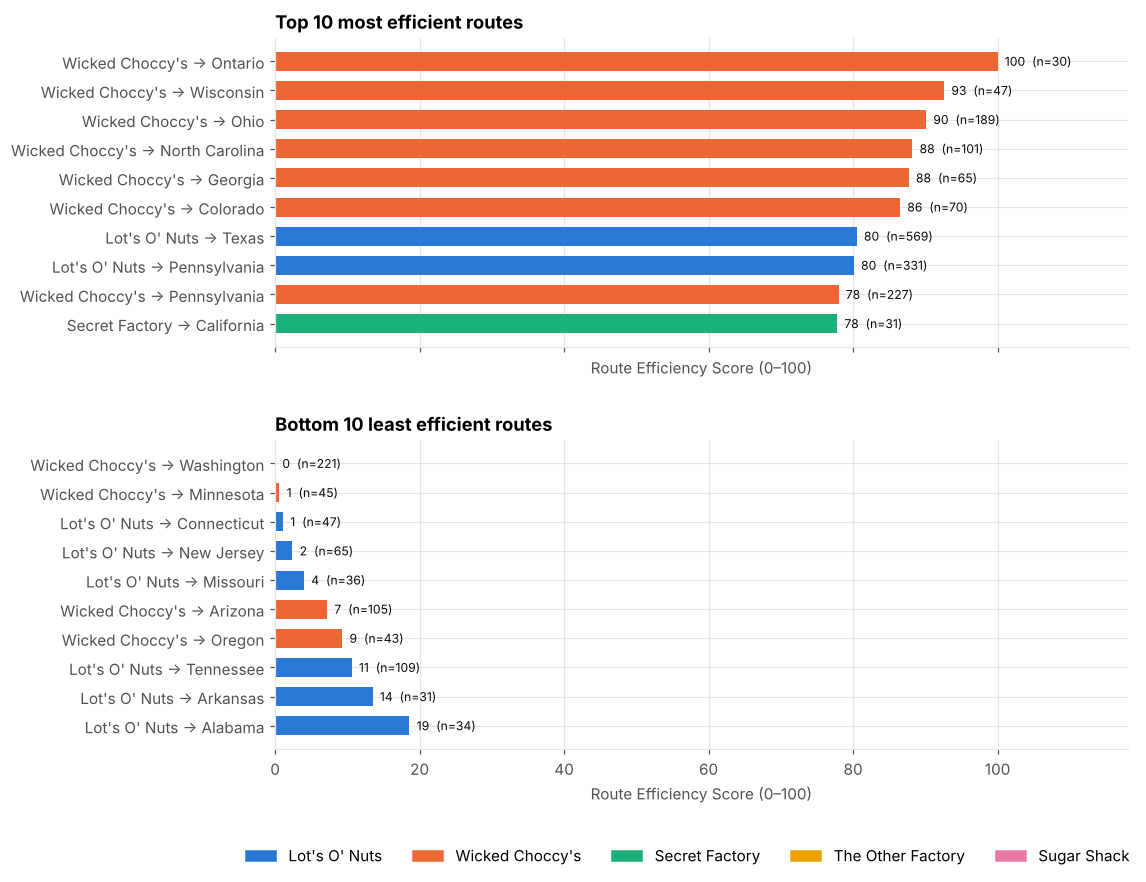

In [13]:
top, bot = elig.head(10), elig.tail(10).iloc[::-1]
fig, ax = plt.subplots(2, 1, figsize=(10, 8.4), sharex=True, gridspec_kw={"hspace": 0.3})
for a, d, t in [(ax[0], top, "Top 10 most efficient routes"), (ax[1], bot, "Bottom 10 least efficient routes")]:
    a.barh(d.index, d["Efficiency Score"], color=[m.FACTORY_COLORS[f] for f in d["Factory"]], height=0.65)
    a.invert_yaxis(); a.set_title(t); a.set_xlabel("Route Efficiency Score (0–100)")
    for i, (s, n) in enumerate(zip(d["Efficiency Score"], d["Shipments"])):
        a.text(s + 1, i, f"{s:.0f}  (n={n})", va="center", fontsize=8, color=INK)
    a.set_xlim(0, 118)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in m.FACTORY_COLORS.values()]
fig.legend(handles, m.FACTORY_COLORS.keys(), ncol=5, frameon=False, loc="lower center", bbox_to_anchor=(.5, -.03))
save(fig, "fig04_route_leaderboard")

**Findings.** The best routes are short, regional lanes with on-time dispatch – Wicked Choccy's (Georgia)
into the Southeast, Ohio and Wisconsin, and Lot's O' Nuts (Arizona) into Texas and California.
The weakest routes combine long distance with above-average delays: **Wicked Choccy's → Washington**
(2,394 mi, 21% breach, 221 shipments) and **→ Oregon / Arizona**, **Lot's O' Nuts → New Jersey / Connecticut**
(2,100+ mi), and Interior lanes such as Lot's O' Nuts → Missouri / Tennessee / Arkansas.
**Wicked Choccy's → Minnesota** has the worst reliability of any route: 36% of shipments breach SLA.
Note that the two big chocolate plants each serve the *other* plant's natural territory – the root cause
tackled in Section 9.

In [14]:
reg = m.route_scorecard(df, "Route (Factory→Region)", min_volume=30)
reg[reg["Eligible"]]

,Factory,Shipments,Avg Lead Time (d),Excess Days,Delay Rate,Avg Distance (mi),Sales,Gross Profit,"Profit per 1,000 mi",Efficiency Score,Eligible
Route (Factory→Region),,,,,,,,,,,
Secret Factory → Interior,Secret Factory,45,3.87,-0.16,0.11,445.25,"1,590.00",806.80,40.27,100.00,True
The Other Factory → Pacific,The Other Factory,32,4.00,-0.05,0.12,"1,642.92",386.25,61.25,1.17,71.80,True
Wicked Choccy's → Atlantic,Wicked Choccy's,1197,4.28,-0.05,0.14,706.31,"15,414.50","10,039.66",11.87,69.10,True
Secret Factory → Atlantic,Secret Factory,72,4.21,-0.05,0.14,766.12,"2,991.25","1,499.85",27.19,66.40,True
Wicked Choccy's → Gulf,Wicked Choccy's,663,4.33,-0.01,0.13,374.07,"8,993.25","5,857.51",23.62,64.50,True
The Other Factory → Atlantic,The Other Factory,38,4.13,-0.19,0.16,927.67,506.75,54.75,1.55,63.60,True
Lot's O' Nuts → Interior,Lot's O' Nuts,1321,4.36,-0.01,0.13,"1,187.90","17,856.86","12,353.56",7.87,49.10,True
Lot's O' Nuts → Atlantic,Lot's O' Nuts,1661,4.21,-0.03,0.14,"2,059.53","22,166.13","15,315.63",4.48,45.50,True
Lot's O' Nuts → Pacific,Lot's O' Nuts,1813,4.24,0.00,0.14,603.59,"24,294.04","16,788.44",15.34,42.70,True


## 7. Geographic bottlenecks

,Region,Country,Shipments,Avg Lead Time (d),Excess Days,Delay Rate,Avg Distance (mi),CI95 low,CI95 high,Significantly slow
State/Province,,,,,,,,,,
Minnesota,Interior,United States,89,4.96,0.43,0.29,"1,179.05",0.17,0.69,True
Missouri,Interior,United States,66,4.50,0.41,0.17,966.01,0.09,0.73,True
Utah,Pacific,United States,53,4.66,0.36,0.00,"1,091.88",0.13,0.60,True
Oklahoma,Interior,United States,66,4.71,0.31,0.12,898.93,0.09,0.54,True
Indiana,Interior,United States,149,4.71,0.20,0.17,"1,140.84",0.02,0.38,True
Washington,Pacific,United States,506,4.38,0.18,0.19,"1,712.72",0.07,0.28,True
Arkansas,Gulf,United States,60,4.57,0.17,0.35,888.71,-0.21,0.55,False
Delaware,Atlantic,United States,96,4.55,0.15,0.10,"1,264.72",-0.05,0.35,False
Connecticut,Atlantic,United States,82,3.98,0.14,0.23,"1,610.73",-0.11,0.38,False


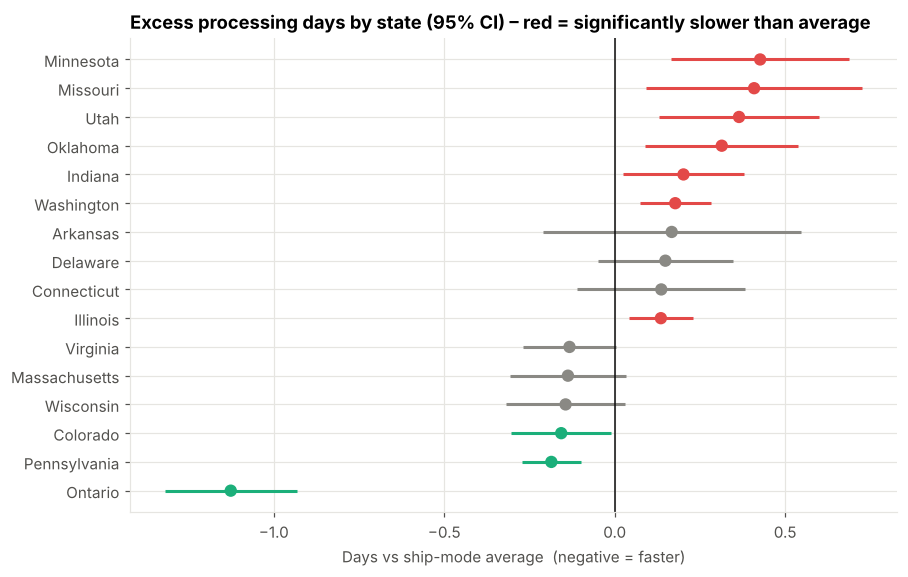

In [15]:
st = m.state_bottlenecks(df, min_volume=50)
display(st.head(12))
plot = pd.concat([st.head(10), st.tail(6)]).sort_values("Excess Days")
fig, ax = plt.subplots(figsize=(9, 5.6))
colors = np.where(plot["Significantly slow"], "#e34948", np.where(plot["CI95 high"] < 0, "#1baf7a", "#8a8984"))
ax.hlines(plot.index, plot["CI95 low"], plot["CI95 high"], color=colors, lw=2)
ax.scatter(plot["Excess Days"], plot.index, color=colors, s=50, zorder=3)
ax.axvline(0, color=INK, lw=1)
ax.set_title("Excess processing days by state (95% CI) – red = significantly slower than average")
ax.set_xlabel("Days vs ship-mode average  (negative = faster)")
save(fig, "fig05_state_bottlenecks")

**Findings.** After removing ship-mode mix, a cluster of **Interior / Upper-Midwest states** is
significantly slower than the network average – Minnesota, Missouri, Oklahoma, Indiana, Illinois – plus
Utah and Washington in the West. Minnesota is the clearest bottleneck (+0.4 days, 29% SLA breach).
Arkansas and Connecticut have high breach rates but on small samples, so they are flagged for monitoring
rather than action.

In [16]:
# Interactive US map (rendered in the Streamlit app; static version shown here)
import plotly.express as px
us = df[df["Country/Region"] == "United States"]
abbr = {"Alabama":"AL","Arizona":"AZ","Arkansas":"AR","California":"CA","Colorado":"CO","Connecticut":"CT","Delaware":"DE",
"District of Columbia":"DC","Florida":"FL","Georgia":"GA","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
"Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD","Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
"Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
"North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI",
"South Carolina":"SC","South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
"West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"}
s = us.groupby("State/Province").agg(Delay=("is_delayed","mean"), Shipments=("Sales","size")).reset_index()
s["code"] = s["State/Province"].map(abbr)
fig = px.choropleth(s, locations="code", locationmode="USA-states", color="Delay", scope="usa",
                    color_continuous_scale=["#f0efec", "#f3b7b6", "#e34948", "#9c1c1c"],
                    hover_name="State/Province", labels={"Delay": "Delay rate"})
fig.update_layout(title="Delay frequency by customer state", margin=dict(l=0, r=0, t=40, b=0))
try:
    fig.write_image(FIG / "delay_map_static.png", scale=2, width=1000, height=560)
except Exception as e:
    print("Static export skipped:", e)
fig

Static export skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




## 8. Does distance drive lead time?
If transit time were part of the measured lead time, longer routes should be slower. We test this directly.

Shipment level: distance vs excess days  Spearman rho = 0.007, p = 0.495
Kruskal-Wallis on excess days by Region          H =     6.4, p = 9.18e-02  (4 groups)
Kruskal-Wallis on excess days by Factory         H =     5.1, p = 2.73e-01  (5 groups)
Kruskal-Wallis on excess days by State/Province  H =   193.2, p = 2.66e-22  (40 groups)


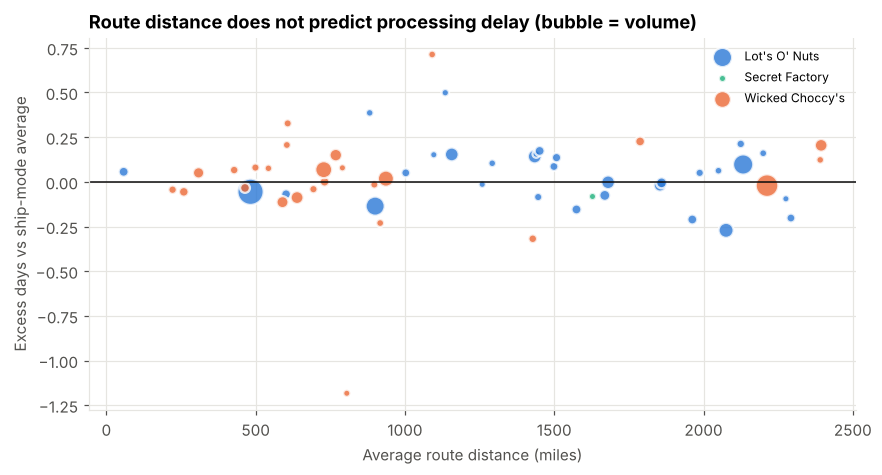

In [17]:
rho, p = stats.spearmanr(df["distance_miles"], df["excess_days"])
print(f"Shipment level: distance vs excess days  Spearman rho = {rho:.3f}, p = {p:.3f}")
for col in ["Region", "Factory", "State/Province"]:
    groups = [g["excess_days"].values for _, g in df.groupby(col) if len(g) >= 30]
    H, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis on excess days by {col:<15} H = {H:7.1f}, p = {p:.2e}  ({len(groups)} groups)")

fig, ax = plt.subplots(figsize=(9, 4.4))
for f, g in elig.groupby("Factory"):
    ax.scatter(g["Avg Distance (mi)"], g["Excess Days"], s=g["Shipments"] / 4 + 15, alpha=.8,
               color=m.FACTORY_COLORS[f], label=f, edgecolor="white", linewidth=1.5)
ax.axhline(0, color=INK, lw=1)
ax.set_xlabel("Average route distance (miles)"); ax.set_ylabel("Excess days vs ship-mode average")
ax.set_title("Route distance does not predict processing delay (bubble = volume)")
ax.legend(frameon=False, fontsize=8)
save(fig, "fig06_distance_vs_delay")

**Findings.** Distance has **no relationship** with processing lead time (ρ ≈ 0.01, p ≈ 0.5), and neither
region nor factory differs significantly once ship mode is controlled for. State-level differences *are*
significant but small (±0.4 days). In other words the measured lead time is **dispatch / order-processing time**,
not transit time – delays are created inside the fulfilment operation, not on the road.

That gives two separate levers:
* **Speed and reliability** → fix order processing capacity (Section 5) and the slow states (Section 7).
* **Cost and real transit time** → shorten the physical distance between factory and customer (Section 9).

## 9. Factory network & sourcing scenarios

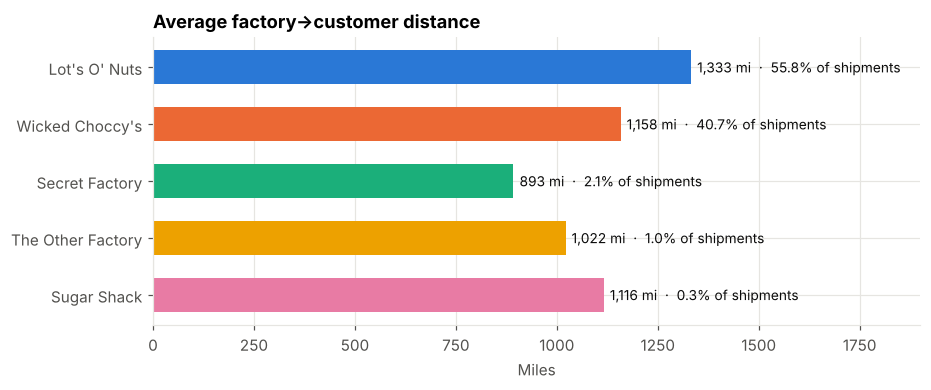

,Shipments,Avg_mi,Share
Factory,,,
Sugar Shack,33,"1,116.33",0.00
The Other Factory,100,"1,021.54",0.01
Secret Factory,217,892.73,0.02
Wicked Choccy's,4152,"1,157.98",0.41
Lot's O' Nuts,5692,"1,332.54",0.56


In [18]:
fd = df.groupby("Factory").agg(Shipments=("Sales","size"), Avg_mi=("distance_miles","mean")).sort_values("Shipments")
fd["Share"] = fd["Shipments"] / fd["Shipments"].sum()
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(fd.index, fd["Avg_mi"], color=[m.FACTORY_COLORS[f] for f in fd.index], height=.6)
for i, (v, s) in enumerate(zip(fd["Avg_mi"], fd["Share"])):
    ax.text(v + 15, i, f"{v:,.0f} mi  ·  {s:.1%} of shipments", va="center", fontsize=9, color=INK)
ax.set_title("Average factory→customer distance"); ax.set_xlabel("Miles"); ax.set_xlim(0, 1900)
save(fig, "fig07_factory_distance")
fd

In [19]:
reloc = m.relocation_scenarios(df)
reloc.style.format({"Current Avg mi": "{:,.0f}", "Best Avg mi": "{:,.0f}", "Unit-miles saved %": "{:.0%}",
                    "Unit-miles saved": "{:,.0f}"})

,Product Name,Division,Shipments,Units,Current Factory,Current Avg mi,Best Factory,Best Avg mi,Unit-miles saved %,Unit-miles saved
13,Wonka Bar -Scrumdiddlyumptious,Chocolate,2064,7743,Lot's O' Nuts,"1,339",Secret Factory,951,29%,"3,002,572"
11,Wonka Bar - Nutty Crunch Surprise,Chocolate,1810,6755,Lot's O' Nuts,"1,328",Secret Factory,931,30%,"2,682,077"
9,Wonka Bar - Fudge Mallows,Chocolate,1818,6914,Lot's O' Nuts,"1,330",Secret Factory,950,29%,"2,629,653"
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,2015,7596,Wicked Choccy's,"1,186",Secret Factory,956,19%,"1,749,633"
10,Wonka Bar - Milk Chocolate,Chocolate,2137,8267,Wicked Choccy's,"1,161",Secret Factory,952,18%,"1,730,156"
5,Laffy Taffy,Sugar,10,27,Sugar Shack,"1,273",Wicked Choccy's,591,54%,"18,429"
8,SweeTARTS,Sugar,10,41,Sugar Shack,"1,074",Secret Factory,773,28%,"12,338"
1,Fizzy Lifting Drinks,Sugar,6,21,Sugar Shack,"1,131",Wicked Choccy's,746,34%,"8,073"
14,Wonka Gum,Other,120,478,Secret Factory,803,The Other Factory,790,2%,"6,249"
7,Nerds,Sugar,4,10,Sugar Shack,"1,199",Wicked Choccy's,711,41%,"4,884"


Moving every chocolate bar to the most central factory is not realistic (capacity, the factories'
specialisations). A more practical option is **nearest-factory fulfilment between the two existing
chocolate plants** – each order is made at whichever of Lot's O' Nuts (AZ) or Wicked Choccy's (GA) is closer
to the customer:

,Current unit-miles,Scenario unit-miles,Reduction,Orders switching factory
Scenario,,,,
Dual-source (AZ + GA),"47,146,528","24,046,279",49%,52%
Tri-source (AZ + GA + IL),"47,146,528","20,509,830",56%,66%


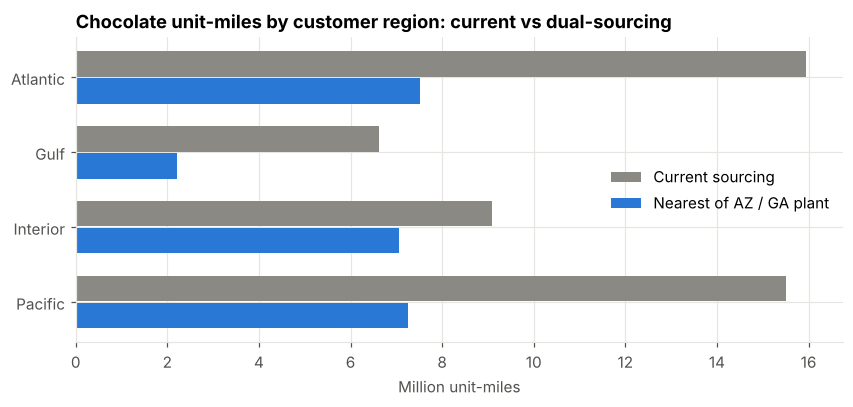

,cur,new
Region,,
Atlantic,15.95,7.53
Gulf,6.61,2.22
Interior,9.08,7.05
Pacific,15.50,7.25


In [20]:
choc = df[df["Division"] == "Chocolate"]
rows = []
for name, fset in {"Dual-source (AZ + GA)": ["Lot's O' Nuts", "Wicked Choccy's"],
                   "Tri-source (AZ + GA + IL)": ["Lot's O' Nuts", "Wicked Choccy's", "Secret Factory"]}.items():
    s = m.nearest_factory_scenario(choc, fset)
    cur = (s["distance_miles"] * s["Units"]).sum(); new = (s["Scenario distance"] * s["Units"]).sum()
    rows.append({"Scenario": name, "Current unit-miles": cur, "Scenario unit-miles": new, "Reduction": 1 - new / cur,
                 "Orders switching factory": (s["Scenario Factory"] != s["Factory"]).mean()})
scen = pd.DataFrame(rows).set_index("Scenario")
display(scen.style.format({"Current unit-miles": "{:,.0f}", "Scenario unit-miles": "{:,.0f}",
                           "Reduction": "{:.0%}", "Orders switching factory": "{:.0%}"}))

s = m.nearest_factory_scenario(choc, ["Lot's O' Nuts", "Wicked Choccy's"])
byreg = s.assign(cur=s["distance_miles"]*s["Units"], new=s["Scenario distance"]*s["Units"]).groupby("Region")[["cur","new"]].sum() / 1e6
fig, ax = plt.subplots(figsize=(9, 3.6)); y = np.arange(len(byreg))
ax.barh(y - .18, byreg["cur"], height=.34, color="#8a8984", label="Current sourcing")
ax.barh(y + .18, byreg["new"], height=.34, color="#2a78d6", label="Nearest of AZ / GA plant")
ax.set_yticks(y, byreg.index); ax.invert_yaxis(); ax.set_xlabel("Million unit-miles")
ax.set_title("Chocolate unit-miles by customer region: current vs dual-sourcing"); ax.legend(frameon=False)
save(fig, "fig08_sourcing_scenario")
byreg

**Findings.** Lot's O' Nuts (Arizona) produces three of the five Wonka Bars and handles 56% of all
shipments, yet ships an average of **1,333 miles** – the longest in the network – because a large share of
its customers are on the East Coast. Letting the two chocolate plants serve whichever customers are closer
cuts chocolate **unit-miles by ~49%**; adding Secret Factory (Illinois) as a third source for the Interior
raises this to ~56%. Sugar and Other products are tiny volumes; Laffy Taffy, Nerds and Fun Dip are made in
northern Minnesota (Sugar Shack) far from most buyers, so they are the first candidates if those lines grow.

## 10. Conclusions & recommendations

| # | Recommendation | Evidence | Expected impact |
|---|---|---|---|
| 1 | **Root-cause the 2025 dispatch slowdown** (staffing, carrier pick-up, cut-off times) and add capacity | SLA breach rose from 7.4% (2024) to 18.7% (2025) within every ship mode | Return SLA breach toward the 2024 level |
| 2 | **Dual-source Wonka Bars** from the AZ and GA plants (nearest-plant routing) | 49% fewer chocolate unit-miles; worst routes are cross-country | Lower freight cost & real transit time |
| 3 | **Fix First Class**: dedicated pick lane / cut-off time | 15% of First Class orders miss their 3-day SLA | Protect premium customers |
| 4 | **Targeted review of bottleneck states** (MN, MO, OK, IN, IL, UT, WA) | Significantly slower than average after controlling for mode | Remove local carrier / hub issues |
| 5 | **Fix the date-shift defect** in the order/ship-date export and add freight cost to the data | 904–1,642-day raw gaps; margins look identical across modes | Trustworthy KPIs for future monitoring |

**Limitations.** Lead time measures processing to dispatch, not delivery; distance is great-circle, not road
miles; freight cost is absent; the product→factory mapping comes from the project brief.